In [1]:
# import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Drivers of Cyberattack Severity: A Data Science Analysis of Financial Loss, User Impact, and Incident Response

### Author: **@AlexanderPanagyurski**, Date: March 2026, Data Science project

## 1. Abstract

This project presents a data science analysis of cyberattack severity, focusing on three key outcome dimensions: financial loss, user impact, and incident response. By integrating multiple cybersecurity datasets from independent sources, the study explores how attack type, target industry, geographic region, vulnerability category, and defense mechanisms relate to the overall severity of cyber incidents. The analysis combines data cleaning, consolidation, exploratory data analysis, statistical reasoning, and predictive modeling to identify patterns and factors associated with more damaging attacks. The goal is to better understand which characteristics of cyber incidents are most strongly linked to high impact and slower resolution, and to demonstrate how data-driven methods can support cybersecurity risk assessment.

## 2. Introduction


In the modern digital world, cybersecurity has become a major concern for governments, businesses, and individual users. As organizations increasingly rely on online services, cloud infrastructure, interconnected devices, and large-scale data systems, they become more exposed to cyber threats such as malware, phishing, ransomware, denial-of-service attacks, and unauthorized access. These incidents can disrupt operations, compromise sensitive information, damage reputation, and create significant economic losses.

The impact of cyberattacks is not uniform. Some incidents have limited consequences and are resolved quickly, while others affect millions of users, result in substantial financial damage, and require long and complex recovery efforts. Because of this, understanding cyberattack severity is an important problem in both research and practice. Identifying the characteristics that are associated with more severe incidents can support better risk assessment, prioritization of defenses, and faster incident response.

## 3. Problem Formulation

The main problem in this project is to understand which factors are associated with more severe cyberattacks. In practice, cyberattack severity is not a single concept, so it is analyzed through three measurable dimensions: financial loss, number of affected users, and incident response time. The project studies how these outcomes vary depending on attack type, industry, vulnerability, defense mechanism, and operational indicators.

## 4. Research Questions and Objectives


Based on the problem formulation, this project investigates cyberattack severity through a set of focused research questions. The analysis is centered on three outcome dimensions: financial loss, user impact, and incident response time. These dimensions are used as practical indicators of how severe a cyber incident is.

#### 4.1. Main Research Question

Which characteristics of cyberattacks are most strongly associated with higher financial loss, greater user impact, and longer incident response times?

#### 4.2. Sub-questions

1. Which attack types are associated with the highest average financial loss?
2. Which industries or sectors experience the greatest user impact from cyber incidents?
3. Which factors are associated with longer incident resolution times?
4. How do vulnerability categories, defense mechanisms, and operational indicators relate to severity?
5. To what extent can severity-related outcomes be estimated or predicted from available cyberattack features?

## 5. Data Exploration

This project uses two independent datasets related to cybersecurity incidents and attacks **[cybersecurity_attacks.csv](https://www.kaggle.com/datasets/teamincribo/cyber-security-attacks/data)**, **[Global_Cybersecurity_Threats_2015-2024.csv](https://www.kaggle.com/datasets/atharvasoundankar/global-cybersecurity-threats-2015-2024)**. 

### 5.1. Dataset 1: [Global Cybersecurity Threats (2015-2024)](https://www.kaggle.com/datasets/atharvasoundankar/global-cybersecurity-threats-2015-2024)

This dataset provides a global, incident-oriented view of cybersecurity threats and is the primary source used to study cyberattack severity in terms of financial loss, user impact, and incident response time. It contains observations from multiple countries, years, attack types, industries, and security contexts. Because it includes both explanatory variables and severity-related outcomes, it serves as the core dataset for the main analytical part of the project.

#### 5.1.1. Load and preview the dataset

In [2]:
# load dataframe 
global_cybersecuirty_threats = pd.read_csv('data/Global_Cybersecurity_Threats_2015-2024.csv')
global_cybersecuirty_threats

,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
0,China,2019,Phishing,Education,80.53,773169,Hacker Group,Unpatched Software,VPN,63
1,China,2019,Ransomware,Retail,62.19,295961,Hacker Group,Unpatched Software,Firewall,71
2,India,2017,Man-in-the-Middle,IT,38.65,605895,Hacker Group,Weak Passwords,VPN,20
3,UK,2024,Ransomware,Telecommunications,41.44,659320,Nation-state,Social Engineering,AI-based Detection,7
4,Germany,2018,Man-in-the-Middle,IT,74.41,810682,Insider,Social Engineering,VPN,68
...,...,...,...,...,...,...,...,...,...,...
2995,UK,2021,Ransomware,Government,51.42,190694,Unknown,Social Engineering,Firewall,52
2996,Brazil,2023,SQL Injection,Telecommunications,30.28,892843,Hacker Group,Zero-day,VPN,26
2997,Brazil,2017,SQL Injection,IT,32.97,734737,Nation-state,Weak Passwords,AI-based Detection,30
2998,UK,2022,SQL Injection,IT,32.17,379954,Insider,Unpatched Software,Firewall,9


#### 5.1.2. Check shape and column names

In [3]:
# Check shape and column names
print("Shape:", global_cybersecuirty_threats.shape)
print("\nColumns:")
print(global_cybersecuirty_threats.columns.tolist())

Shape: (3000, 10)

Columns:
['Country', 'Year', 'Attack Type', 'Target Industry', 'Financial Loss (in Million $)', 'Number of Affected Users', 'Attack Source', 'Security Vulnerability Type', 'Defense Mechanism Used', 'Incident Resolution Time (in Hours)']


To improve code readability and follow Python naming conventions, will rename dataframe columns to lowercase snake_case format. This makes later analysis, visualization, and modeling steps easier to write and maintain.

In [4]:
# rename the columns to follow python convention (snake_case) 
global_cybersecuirty_threats = global_cybersecuirty_threats.rename(columns={
    "Country": "country",
    "Year": "year",
    "Attack Type": "attack_type",
    "Target Industry": "target_industry",
    "Financial Loss (in Million $)": "financial_loss_in_millions_usd",
    "Number of Affected Users": "number_of_affected_users",
    "Attack Source": "attack_source",
    "Security Vulnerability Type": "security_vulnerability_type",
    "Defense Mechanism Used": "defense_mechanism_used",
    "Incident Resolution Time (in Hours)": "incident_resolution_time_in_hours"
})

In [5]:
print("\nColumns:")
print(global_cybersecuirty_threats.columns.tolist())


Columns:
['country', 'year', 'attack_type', 'target_industry', 'financial_loss_in_millions_usd', 'number_of_affected_users', 'attack_source', 'security_vulnerability_type', 'defense_mechanism_used', 'incident_resolution_time_in_hours']


#### 5.1.3. Inspect data types and missing values

In [6]:
# checks if at least one missing value exists per column
global_cybersecuirty_threats.isna().any()

country                              False
year                                 False
attack_type                          False
target_industry                      False
financial_loss_in_millions_usd       False
number_of_affected_users             False
attack_source                        False
security_vulnerability_type          False
defense_mechanism_used               False
incident_resolution_time_in_hours    False
dtype: bool

#### 5.1.4. Summary statistics

In [7]:
global_cybersecuirty_threats.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country,3000,10,UK,321,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,3000.0,NaN,NaN,NaN,2019.570333,2.857932,2015.0,2017.0,2020.0,2022.0,2024.0
attack_type,3000,6,DDoS,531,NaN,NaN,NaN,NaN,NaN,NaN,NaN
target_industry,3000,7,IT,478,NaN,NaN,NaN,NaN,NaN,NaN,NaN
financial_loss_in_millions_usd,3000.0,NaN,NaN,NaN,50.49297,28.791415,0.5,25.7575,50.795,75.63,99.99
number_of_affected_users,3000.0,NaN,NaN,NaN,504684.136333,289944.084972,424.0,255805.25,504513.0,758088.5,999635.0
attack_source,3000,4,Nation-state,794,NaN,NaN,NaN,NaN,NaN,NaN,NaN
security_vulnerability_type,3000,4,Zero-day,785,NaN,NaN,NaN,NaN,NaN,NaN,NaN
defense_mechanism_used,3000,5,Antivirus,628,NaN,NaN,NaN,NaN,NaN,NaN,NaN
incident_resolution_time_in_hours,3000.0,NaN,NaN,NaN,36.476,20.570768,1.0,19.0,37.0,55.0,72.0


1. `country`
   - 3000 values
   - 10 unique countries
   - most frequent country: UK
   - frequency of UK: 321

**Observation:**

This is a **categorical geographic variable** describing where the incident occurred.
There are only 10 countries in the dataset, so the international coverage is broad but still limited. The UK appears most often, but not overwhelmingly, which suggests the country distribution is relatively balanced rather than dominated by a single location.

2. `year`
    - mean: 2019.57
    - standard deviation: 2.86
    - min: 2015
    - 25%: 2017
    - median: 2020
    - 75%: 2022
    - max: 2024

**Observation:**

This column covers the period from 2015 to 2024, which gives a 10-year time span. The median year is 2020, meaning the observations are centered around the middle of that period. The spread is moderate, and the values appear well distributed across time.

3. `attack_type`
   - 3000 values
   - 6 unique attack types
   - most frequent type: DDoS
   - frequency: 531

**Observation:**

This is one of the most important explanatory variables in the dataset. With only 6 categories, it is easy to compare attack types directly. DDoS is the most common category, but again not to an extreme degree, so the variable looks reasonably balanced.

4. `target_industry`
    - 3000 values
    - 7 unique industries
    - most frequent industry: IT
    - frequency: 478

**Observation:**

This variable describes which industry was targeted by the attack. There are 7 sectors, which is enough for meaningful comparison without making the analysis too fragmented. IT is the most frequent, which is plausible given the project topic.

5. `financial_loss_in_millions_usd`
   - mean: 50.49
   - standard deviation: 28.79
   - min: 0.5
   - 25%: 25.76
   - median: 50.80
   - 75%: 75.63
   - max: 99.99

**Observation:**

This is one of the main severity outcome variables. The average loss is around 50.5 million USD, and the median is very close to the mean, which suggests the distribution is fairly symmetric rather than heavily skewed. The range is wide, from 0.5 million to almost 100 million USD, meaning the dataset includes both low-impact and high-impact incidents.

The standard deviation is also large, showing substantial variation in financial damage across incidents.

6. `number_of_affected_users`
    - mean: 504 684
    - standard deviation: 289 944
    - min: 424
    - 25%: 255 805
    - median: 504 513
    - 75%: 758 089
    - max: 999 635

**Observation:**

This is the second major severity outcome variable. The average and median are almost identical, which again suggests a fairly symmetric distribution. The range is very large: some incidents affect only a few hundred users, while others affect nearly one million.

The large standard deviation indicates strong variation in user impact.
    
7. `attack_source`
    - 3000 values
    - 4 unique categories
    - most frequent source: Nation-state
    - frequency: 794

**Observation:**

This variable identifies the origin or actor category behind the attack. Only 4 source categories are present, which makes it simple to compare groups. Nation-state attacks are the most frequent, though the difference does not appear extreme.

8. `security_vulnerability_type`
    - 3000 values
    - 4 unique categories
    - most frequent category: Zero-day
    - frequency: 785

**Observation:**

This variable describes the type of security weakness exploited in the incident. There are only 4 categories, which makes the variable easy to analyze. Zero-day vulnerabilities are the most common in the dataset.

9. `defense_mechanism_used`
    - 3000 values
    - 5 unique categories
    - most frequent defense: Antivirus
    - frequency: 628

**Observation:**

This variable shows which defense mechanism was used in the incident context. The most frequent category is antivirus. Since there are 5 categories, it should be manageable for comparison and visualization.

10. `incident_resolution_time_in_hours`
    - mean: 36.48
    - standard deviation: 20.57
    - min: 1
    - 25%: 19
    - median: 37
    - 75%: 55
    - max: 72

**Observation:**

This is the third major severity outcome variable. The average resolution time is about 36.5 hours, with a median of 37 hours, so again the distribution appears roughly symmetric. The incidents range from very fast resolution (1 hour) to much slower cases (72 hours), giving enough variability for analysis.

The standard deviation shows that response time varies substantially between incidents.

#### 5.1.5. Unique values for categorical columns

In [8]:
categorical_cols = [
    "country",
    "attack_type",
    "target_industry",
    "attack_source",
    "security_vulnerability_type",
    "defense_mechanism_used"
]

for col in categorical_cols:
    print(f"\n{col} ({global_cybersecuirty_threats[col].nunique()} unique values):")
    print(global_cybersecuirty_threats[col].value_counts())


country (10 unique values):
country
UK           321
Brazil       310
India        308
Japan        305
France       305
Australia    297
Russia       295
Germany      291
USA          287
China        281
Name: count, dtype: int64

attack_type (6 unique values):
attack_type
DDoS                 531
Phishing             529
SQL Injection        503
Ransomware           493
Malware              485
Man-in-the-Middle    459
Name: count, dtype: int64

target_industry (7 unique values):
target_industry
IT                    478
Banking               445
Healthcare            429
Retail                423
Education             419
Government            403
Telecommunications    403
Name: count, dtype: int64

attack_source (4 unique values):
attack_source
Nation-state    794
Unknown         768
Insider         752
Hacker Group    686
Name: count, dtype: int64

security_vulnerability_type (4 unique values):
security_vulnerability_type
Zero-day              785
Social Engineering    747
Unpat

The categorical variables are well distributed across their respective categories, with no extreme imbalance or rare groups. This is helpful for comparative analysis, since it allows attack types, industries, countries, and vulnerability categories to be studied on a more equal basis. At the same time, the unusually regular category frequencies suggest that the dataset may be curated or synthetic, which should be considered when interpreting the findings.

#### 5.1.6. Summary of Dataset 1 Exploration

The first dataset, [Global Cybersecurity Threats (2015-2024)](https://www.kaggle.com/datasets/atharvasoundankar/global-cybersecurity-threats-2015-2024), is the main dataset in this project because it contains the most important variables related to cyberattack severity. It includes 3000 rows and 10 columns, and the initial exploration showed that the dataset is clean and complete, with no missing values. This makes it a good starting point for the analysis.

One of the strongest parts of this dataset is that it contains three clear numeric variables that can be used as severity indicators: `financial_loss_in_millions_usd`, `number_of_affected_users`, and `incident_resolution_time_in_hours`. These variables have a wide range of values, which means they can support meaningful comparisons and further statistical analysis. Also, the mean and median values are quite close, so the distributions do not look extremely skewed at first sight.

The categorical variables, such as `country`, `attack_type`, `target_industry`, `attack_source`, `security_vulnerability_type` and `defense_mechanism_used`, are also useful for the project. Their categories are relatively balanced, which is helpful because it allows fairer comparisons between groups. For example, no single country or attack type completely dominates the dataset. This is good for visualization, grouped analysis, and later modeling.

At the same time, the data looks very regular and balanced, which may mean that it is a curated or partly synthetic dataset rather than raw real-world cybersecurity records. This does not make it useless, but it is important to keep in mind when interpreting the results. Because of this, the analysis will focus more on finding patterns and relationships in the data, rather than making very strong claims about the real world.

Overall, this dataset is well structured and highly relevant to the topic of the project. It provides both the outcome variables needed to measure cyberattack severity and the context variables needed to explain it. For this reason, it will be used as the core dataset in the next stages of the analysis.

### 5.2. Dataset 2: [Cyber Security Attacks](https://www.kaggle.com/datasets/teamincribo/cyber-security-attacks/data)

The [Cyber Security Attacks](https://www.kaggle.com/datasets/teamincribo/cyber-security-attacks/data) dataset gives a more technical perspective on cyber incidents. It contains variables related to network traffic, attack behavior, anomaly detection, and security response. This is useful for the project because it helps explore cyberattack severity not only through financial loss and affected users, but also through operational indicators such as severity level, anomaly score, and action taken. In this way, the dataset adds an important second perspective to the analysis.

#### 5.2.1 Load and preview the dataset

In [9]:
# load dataframe
cybersecurity_attacks = pd.read_csv('data/cybersecurity_attacks.csv')
cybersecurity_attacks.head()

,Timestamp,Source IP Address,Destination IP Address,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Payload Data,...,Action Taken,Severity Level,User Information,Device Information,Network Segment,Geo-location Data,Proxy Information,Firewall Logs,IDS/IPS Alerts,Log Source
0,2023-05-30 06:33:58,103.216.15.12,84.9.164.252,31225,17616,ICMP,503,Data,HTTP,Qui natus odio asperiores nam. Optio nobis ius...,...,Logged,Low,Reyansh Dugal,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment A,"Jamshedpur, Sikkim",150.9.97.135,Log Data,NaN,Server
1,2020-08-26 07:08:30,78.199.217.198,66.191.137.154,17245,48166,ICMP,1174,Data,HTTP,Aperiam quos modi officiis veritatis rem. Omni...,...,Blocked,Low,Sumer Rana,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment B,"Bilaspur, Nagaland",NaN,Log Data,NaN,Firewall
2,2022-11-13 08:23:25,63.79.210.48,198.219.82.17,16811,53600,UDP,306,Control,HTTP,Perferendis sapiente vitae soluta. Hic delectu...,...,Ignored,Low,Himmat Karpe,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...,Segment C,"Bokaro, Rajasthan",114.133.48.179,Log Data,Alert Data,Firewall
3,2023-07-02 10:38:46,163.42.196.10,101.228.192.255,20018,32534,UDP,385,Data,HTTP,Totam maxime beatae expedita explicabo porro l...,...,Blocked,Medium,Fateh Kibe,Mozilla/5.0 (Macintosh; PPC Mac OS X 10_11_5; ...,Segment B,"Jaunpur, Rajasthan",NaN,NaN,Alert Data,Firewall
4,2023-07-16 13:11:07,71.166.185.76,189.243.174.238,6131,26646,TCP,1462,Data,DNS,Odit nesciunt dolorem nisi iste iusto. Animi v...,...,Blocked,Low,Dhanush Chad,Mozilla/5.0 (compatible; MSIE 5.0; Windows NT ...,Segment C,"Anantapur, Tripura",149.6.110.119,NaN,Alert Data,Firewall


#### 5.2.2. Check shape and column names

In [10]:
# Check shape and column names
print("Shape:", cybersecurity_attacks.shape)
print("\nColumns:")
print(cybersecurity_attacks.columns.tolist())

Shape: (40000, 25)

Columns:
['Timestamp', 'Source IP Address', 'Destination IP Address', 'Source Port', 'Destination Port', 'Protocol', 'Packet Length', 'Packet Type', 'Traffic Type', 'Payload Data', 'Malware Indicators', 'Anomaly Scores', 'Alerts/Warnings', 'Attack Type', 'Attack Signature', 'Action Taken', 'Severity Level', 'User Information', 'Device Information', 'Network Segment', 'Geo-location Data', 'Proxy Information', 'Firewall Logs', 'IDS/IPS Alerts', 'Log Source']


To improve code readability and follow Python naming conventions, will rename dataframe columns to lowercase snake_case format. This makes later analysis, visualization, and modeling steps easier to write and maintain.

In [11]:
cybersecurity_attacks.columns = (
    cybersecurity_attacks.columns
    .str.lower()
    .str.replace(r'[^a-z0-9]+', '_', regex=True)
    .str.strip('_')
)

print("\nColumns:")
print(cybersecurity_attacks.columns.tolist())


Columns:
['timestamp', 'source_ip_address', 'destination_ip_address', 'source_port', 'destination_port', 'protocol', 'packet_length', 'packet_type', 'traffic_type', 'payload_data', 'malware_indicators', 'anomaly_scores', 'alerts_warnings', 'attack_type', 'attack_signature', 'action_taken', 'severity_level', 'user_information', 'device_information', 'network_segment', 'geo_location_data', 'proxy_information', 'firewall_logs', 'ids_ips_alerts', 'log_source']


#### 5.2.3. Inspect data types and missing values

In [12]:
# checks if at least one missing value exists per column
cybersecurity_attacks.isna().any()

timestamp                 False
source_ip_address         False
destination_ip_address    False
source_port               False
destination_port          False
protocol                  False
packet_length             False
packet_type               False
traffic_type              False
payload_data              False
malware_indicators         True
anomaly_scores            False
alerts_warnings            True
attack_type               False
attack_signature          False
action_taken              False
severity_level            False
user_information          False
device_information        False
network_segment           False
geo_location_data         False
proxy_information          True
firewall_logs              True
ids_ips_alerts             True
log_source                False
dtype: bool

**Observation:**

The second dataset has some missing values, but they appear only in a few columns related to security monitoring, such as `malware_indicators`, `alerts_warnings`, `proxy_information`, `firewall_logs`, and `ids_ips_alerts`. The main variables used for analysis, like `attack_type`, `anomaly_scores`, `severity_level`, and `action_taken`, are complete. Because of this, the dataset can still be used for the project, although some of the additional context columns may need to be cleaned or handled more carefully later.

Let's check the number and percentage of missing values, not only whether they exist

In [13]:
missing_counts = cybersecurity_attacks.isna().sum()
missing_percent = (cybersecurity_attacks.isna().mean() * 100).round(2)

missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percent": missing_percent
})

missing_summary[missing_summary["missing_count"] > 0].sort_values(
    by="missing_count", ascending=False
)

,missing_count,missing_percent
alerts_warnings,20067,50.17
ids_ips_alerts,20050,50.12
malware_indicators,20000,50.00
firewall_logs,19961,49.90
proxy_information,19851,49.63


**Missing Values Analysis**

Each of these columns has missing values in about 50% of the observations. This is a significant amount, so these variables need special attention in the cleaning stage.
Since the missing values are around 50% for these columns, we should not fill them with random values or averages. Better options later are:

- keep them, but treat missing as "Unknown" or "Not Recorded" if they are categorical/text-like
- exclude some of them from the main modeling if they add too much uncertainty
- mention clearly that these variables are incomplete and are used carefully

#### 5.2.4. Summary statistics

In [14]:
cybersecurity_attacks.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
timestamp,40000,39997,2022-04-17 20:05:34,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source_ip_address,40000,40000,138.156.5.40,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
destination_ip_address,40000,40000,91.54.135.213,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source_port,40000.0,NaN,NaN,NaN,32970.35645,18560.425604,1027.0,16850.75,32856.0,48928.25,65530.0
destination_port,40000.0,NaN,NaN,NaN,33150.86865,18574.668842,1024.0,17094.75,33004.5,49287.0,65535.0
protocol,40000,3,ICMP,13429,NaN,NaN,NaN,NaN,NaN,NaN,NaN
packet_length,40000.0,NaN,NaN,NaN,781.452725,416.044192,64.0,420.0,782.0,1143.0,1500.0
packet_type,40000,2,Control,20237,NaN,NaN,NaN,NaN,NaN,NaN,NaN
traffic_type,40000,3,DNS,13376,NaN,NaN,NaN,NaN,NaN,NaN,NaN
payload_data,40000,40000,Fugiat tenetur natus perferendis. Mollitia bla...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


- `timestamp`

   Almost every row has a different timestamp (39997 unique values out of 40000), so this column is very detailed. It can be useful for extracting features like year, month, hour, or day of week, but not very useful in its raw form.

- `source_ip_address` and `destination_ip_address`

    These columns have almost completely unique values. That means they behave more like identifiers than analytical variables. They may not be very useful for general pattern analysis, unless we do some feature extraction later.


- `source_port` and `destination_port`

    These are numeric columns, but they are better treated as technical network features than normal continuous variables. Their values are spread across a wide range, and the averages are around 33000, which suggests there is a lot of variation in the used ports.

- `protocol`

  There are only 3 unique values, and the most common one is `ICMP`. This is a useful categorical variable because it is simple and can be compared easily across severity levels or attack types.

- `packet_length`

  This looks like an important numeric variable. The values range from `64` to `1500`, with mean around `781`, which shows a wide spread. This column may be useful when studying technical differences between attacks.

- `packet_type`

  Only **2 categories** appear here, and `Control` is slightly more common. This is a simple categorical variable that may help describe attack behavior.

- `traffic_type`

  There are **3 traffic categories**, and `DNS` is the most frequent. This seems useful for comparing how attack severity differs by traffic type.

- `payload_data`

  This column has unique text in every row, so it is not very practical for standard analysis. It may contain useful information, but it looks more suitable for text analysis, which is outside the main scope of this project.


- `malware_indicators`

  This column has a special pattern: only half of the rows are filled, and all non-missing values are the same (`IoC Detected`). This means it may be more useful as a binary indicator (`present` / `missing`) rather than as a text variable.


- `anomaly_scores`

  This is one of the most useful numeric columns in the dataset. The values range from `0` to `100`, and the mean is around `50`. Since the values are spread quite evenly, this variable looks suitable for severity-related analysis and modeling.

  
- `alerts_warnings`

  This column also has many missing values, and all non-missing entries are the same (`Alert Triggered`). Like `malware_indicators`, it is better understood as a yes/no signal rather than a rich categorical feature.


- `attack_type`

  There are only **3 attack types**, and `DDoS` is the most common. This is clearly one of the key variables in the dataset and will probably be important in the analysis.

- `attack_signature`

  This column has only **2 categories**, with `Known Pattern A` being slightly more common. It may be useful, but it looks a bit limited and may not add much depth by itself.

- `action_taken`

  There are **3 categories**, and `Blocked` is the most frequent. This is a useful variable because it is directly connected to incident response, which matches your project topic.

- `severity_level`

  This is one of the most important columns here. It has 3 levels, and `Medium` is the most common. This variable can be used as a direct technical severity measure.

- `user_information`

  This column has many unique values, so it behaves more like an identifier than a clean analytical feature. It is probably not very useful for the main analysis


- `device_information`

  This column also has many unique values, but fewer than user information. It may contain some patterns, but in raw form it is probably too detailed and noisy.


- `network_segment`

  There are **3 categories**, and they are very evenly distributed. This looks like a useful variable for grouped comparisons.


- `geo_location_data`

  This column has many unique values (`8723`), so it is more detailed than the country variable in the first dataframe `global_cybersecuirty_threats`. It may be useful later, but probably needs simplification first.

- `proxy_information`

  About half of the rows are missing, and the non-missing values are mostly unique. This column may be too incomplete and too specific to be very useful in the main analysis.

- `firewall_logs`

  This has many missing values, and all non-missing rows contain the same value (`Log Data`). So again, it is better treated as a binary flag than as a real categorical variable.

- `ids_ips_alerts`

  This is very similar to `firewall_logs`: many missing values, and only one repeated non-missing value (`Alert Data`). It may still be useful as an indicator, but not as a detailed feature.

- `log_source`

  There are only **2 categories**, and `Firewall` is slightly more common. This is a simple but potentially useful variable for comparing event origin.


**Key Observations**

`cybersecurity_attacks` dataframe ([Cyber Security Attacks](https://www.kaggle.com/datasets/teamincribo/cyber-security-attacks/data) dataset) is more technical and less clean than `global_cybersecuirty_threats` dataframe ([Global Cybersecurity Threats (2015-2024)](https://www.kaggle.com/datasets/atharvasoundankar/global-cybersecurity-threats-2015-2024) dataset). Variables such as `attack_type`, `protocol`, `traffic_type`, `action_taken`, `severity_level`, `network_segment`, and `log_source` look useful for the main analysis because they are easy to compare.

Among the numeric columns, `packet_length` and especially `anomaly_scores` seem the most useful for studying technical severity. In contrast, columns like `source_ip_address` and `destination_ip_address`, `payload_data`, `user_information`, and `proxy_information` are too detailed to be very useful in raw form.

Also, some columns with many missing values, such as `malware_indicators`, `alerts_warnings`, `firewall_logs`, and `ids_ips_alerts`, contain only one repeated non-missing value. Because of this, they may work better as simple yes/no indicators.

Overall, this dataset adds a more operational view of cyber incidents and complements [Global Cybersecurity Threats (2015-2024)](https://www.kaggle.com/datasets/atharvasoundankar/global-cybersecurity-threats-2015-2024) dataset well.

#### 5.2.5. Unique values for categorical columns

In [15]:
categorical_cols = [
    "protocol",
    "packet_type",
    "traffic_type",
    "malware_indicators",
    "alerts_warnings",
    "attack_type",
    "attack_signature",
    "action_taken",
    "severity_level",
    "network_segment",
    "firewall_logs",
    "ids_ips_alerts",
    "log_source"
]

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(f"Unique non-missing values: {cybersecurity_attacks[col].nunique(dropna=True)}")
    print(cybersecurity_attacks[col].value_counts(dropna=False))


--- protocol ---
Unique non-missing values: 3
protocol
ICMP    13429
UDP     13299
TCP     13272
Name: count, dtype: int64

--- packet_type ---
Unique non-missing values: 2
packet_type
Control    20237
Data       19763
Name: count, dtype: int64

--- traffic_type ---
Unique non-missing values: 3
traffic_type
DNS     13376
HTTP    13360
FTP     13264
Name: count, dtype: int64

--- malware_indicators ---
Unique non-missing values: 1
malware_indicators
IoC Detected    20000
NaN             20000
Name: count, dtype: int64

--- alerts_warnings ---
Unique non-missing values: 1
alerts_warnings
NaN                20067
Alert Triggered    19933
Name: count, dtype: int64

--- attack_type ---
Unique non-missing values: 3
attack_type
DDoS         13428
Malware      13307
Intrusion    13265
Name: count, dtype: int64

--- attack_signature ---
Unique non-missing values: 2
attack_signature
Known Pattern A    20076
Known Pattern B    19924
Name: count, dtype: int64

--- action_taken ---
Unique non-miss

The categorical variables in Dataset 2 are generally very balanced. Most of the main columns, such as `protocol`, `traffic_type`, `attack_type`, `action_taken`, `severity_level`, `network_segment`, and `log_source`, have only a small number of categories and the counts are very similar. This is useful because it supports fair comparisons between groups and makes the variables suitable for visualization and modeling.

At the same time, some columns such as `malware_indicators`, `alerts_warnings`, `firewall_logs`, and `ids_ips_alerts` have a different pattern. They contain only one non-missing value and many missing values, so they are better understood as binary indicators showing whether that type of information is present or not.

Overall, the categorical structure of Dataset 2 is clean and easy to work with, especially for studying technical severity and response-related patterns.

#### 5.2.6. Summary of Dataset 2 Exploration

The second dataset, [Cyber Security Attacks](https://www.kaggle.com/datasets/teamincribo/cyber-security-attacks/data), adds a more technical and operational view to the project. Unlike the first dataset, which focuses more on outcomes such as financial loss, affected users, and incident resolution time, this dataset describes the attacks from a system and network perspective. It includes variables such as protocol, traffic type, packet length, anomaly score, attack type, action taken, and severity level.

The exploration showed that this dataset is larger and more detailed, but also less clean than the first one. Several columns contain missing values, especially `malware_indicators`, `alerts_warnings`, `proxy_information`, `firewall_logs`, and `ids_ips_alerts`, where the missing share is close to 50%. However, the main variables used for analysis are complete, so the dataset is still useful for the project.

Another important observation is that most of the main categorical variables are well balanced. Columns such as protocol, `traffic_type`, `attack_type`, `action_taken`, `severity_level`, `network_segment`, and `log_source` have only a few categories, and their counts are very similar. This is helpful because it makes comparison between groups easier and more reliable.

Overall, this dataset complements [Global Cybersecurity Threats (2015-2024)](https://www.kaggle.com/datasets/atharvasoundankar/global-cybersecurity-threats-2015-2024) well. While the first dataset helps measure cyberattack severity through business impact, this second dataset adds information about technical behavior, monitoring, and response. For this reason, it will be used as the supporting dataset in the next stages of the project.

## 6. Data Cleaning and Validation

### 6.1. Data Cleaning and Validation: [Global Cybersecurity Threats (2015-2024)](https://www.kaggle.com/datasets/atharvasoundankar/global-cybersecurity-threats-2015-2024)

In [16]:
global_cybersecuirty_threats

,country,year,attack_type,target_industry,financial_loss_in_millions_usd,number_of_affected_users,attack_source,security_vulnerability_type,defense_mechanism_used,incident_resolution_time_in_hours
0,China,2019,Phishing,Education,80.53,773169,Hacker Group,Unpatched Software,VPN,63
1,China,2019,Ransomware,Retail,62.19,295961,Hacker Group,Unpatched Software,Firewall,71
2,India,2017,Man-in-the-Middle,IT,38.65,605895,Hacker Group,Weak Passwords,VPN,20
3,UK,2024,Ransomware,Telecommunications,41.44,659320,Nation-state,Social Engineering,AI-based Detection,7
4,Germany,2018,Man-in-the-Middle,IT,74.41,810682,Insider,Social Engineering,VPN,68
...,...,...,...,...,...,...,...,...,...,...
2995,UK,2021,Ransomware,Government,51.42,190694,Unknown,Social Engineering,Firewall,52
2996,Brazil,2023,SQL Injection,Telecommunications,30.28,892843,Hacker Group,Zero-day,VPN,26
2997,Brazil,2017,SQL Injection,IT,32.97,734737,Nation-state,Weak Passwords,AI-based Detection,30
2998,UK,2022,SQL Injection,IT,32.17,379954,Insider,Unpatched Software,Firewall,9


In [17]:
global_cybersecuirty_threats.dtypes

country                               object
year                                   int64
attack_type                           object
target_industry                       object
financial_loss_in_millions_usd       float64
number_of_affected_users               int64
attack_source                         object
security_vulnerability_type           object
defense_mechanism_used                object
incident_resolution_time_in_hours      int64
dtype: object

In step **5.1.3 Inspect data types and missing values**, we found that the `global_cybersecuirty_threats` dataframe has no missing values. The columns `country`, `attack_type`, `target_industry`, `attack_source`, `security_vulnerability_type`, and `defense_mechanism_used` are stored as `object`, which usually means they contain text values. To confirm this, I can inspect their unique values and check for problems such as empty strings or whitespaces. After cleaning them if needed, these columns can be converted to the category type, because they represent repeated categories and not free text.

In [18]:
def print_unique_values(dataframe, cols):
    """
    Print sorted unique values for specified columns in a DataFrame.

    Parameters:
        df (pd.DataFrame): The dataframe to inspect
        cols (list): List of column names to check
    """
    for col in cols:
        print(f"\n--- {col} ---")
        
        if col not in dataframe.columns:
            print("Column not found in DataFrame")
            continue
        
        print("Unique values:")
        print(dataframe[col].unique())

In [19]:
cols_to_check = [
    "country",
    "attack_type",
    "target_industry",
    "attack_source",
    "security_vulnerability_type",
    "defense_mechanism_used"
]

print_unique_values(global_cybersecuirty_threats, cols_to_check)


--- country ---
Unique values:
['China' 'India' 'UK' 'Germany' 'France' 'Australia' 'Russia' 'Brazil'
 'Japan' 'USA']

--- attack_type ---
Unique values:
['Phishing' 'Ransomware' 'Man-in-the-Middle' 'DDoS' 'SQL Injection'
 'Malware']

--- target_industry ---
Unique values:
['Education' 'Retail' 'IT' 'Telecommunications' 'Government' 'Banking'
 'Healthcare']

--- attack_source ---
Unique values:
['Hacker Group' 'Nation-state' 'Insider' 'Unknown']

--- security_vulnerability_type ---
Unique values:
['Unpatched Software' 'Weak Passwords' 'Social Engineering' 'Zero-day']

--- defense_mechanism_used ---
Unique values:
['VPN' 'Firewall' 'AI-based Detection' 'Antivirus' 'Encryption']


In [20]:
categorical_cols = cols_to_check

for col in categorical_cols:
    global_cybersecuirty_threats[col] = global_cybersecuirty_threats[col].astype("category")

global_cybersecuirty_threats.dtypes

country                              category
year                                    int64
attack_type                          category
target_industry                      category
financial_loss_in_millions_usd        float64
number_of_affected_users                int64
attack_source                        category
security_vulnerability_type          category
defense_mechanism_used               category
incident_resolution_time_in_hours       int64
dtype: object

After checking the unique values, no empty strings or formatting problems were found in the main text-based columns. Since these variables represent repeated categories, they were converted from `object` to `category` to make the dataset more suitable for analysis.

Make sure the dataset does not contain duplicate records.

In [21]:
global_cybersecuirty_threats.duplicated().sum()

np.int64(0)

After checking missing values, duplicate records, categorical values, and data types, the `global_cybersecuirty_threats` dataframe appears clean and consistent enough for further analysis. The validity of the numeric ranges was already confirmed in **5.1.4 Summary statistics**, where the values for `year`, `financial_loss_in_millions_usd`, `number_of_affected_users`, and `incident_resolution_time_in_hours` were shown to be within reasonable bounds. Meaning `year` is between 2015 and 2024 as the title of the dataset suggests it should be, `financial_loss_in_millions_usd`, `number_of_affected_users`, `incident_resolution_time_in_hours` are not negative.

### 6.2. Data Cleaning and Validation: [Cyber Security Attacks](https://www.kaggle.com/datasets/teamincribo/cyber-security-attacks/data)

In [22]:
cybersecurity_attacks.head(30)

,timestamp,source_ip_address,destination_ip_address,source_port,destination_port,protocol,packet_length,packet_type,traffic_type,payload_data,...,action_taken,severity_level,user_information,device_information,network_segment,geo_location_data,proxy_information,firewall_logs,ids_ips_alerts,log_source
0,2023-05-30 06:33:58,103.216.15.12,84.9.164.252,31225,17616,ICMP,503,Data,HTTP,Qui natus odio asperiores nam. Optio nobis ius...,...,Logged,Low,Reyansh Dugal,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment A,"Jamshedpur, Sikkim",150.9.97.135,Log Data,NaN,Server
1,2020-08-26 07:08:30,78.199.217.198,66.191.137.154,17245,48166,ICMP,1174,Data,HTTP,Aperiam quos modi officiis veritatis rem. Omni...,...,Blocked,Low,Sumer Rana,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment B,"Bilaspur, Nagaland",NaN,Log Data,NaN,Firewall
2,2022-11-13 08:23:25,63.79.210.48,198.219.82.17,16811,53600,UDP,306,Control,HTTP,Perferendis sapiente vitae soluta. Hic delectu...,...,Ignored,Low,Himmat Karpe,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...,Segment C,"Bokaro, Rajasthan",114.133.48.179,Log Data,Alert Data,Firewall
3,2023-07-02 10:38:46,163.42.196.10,101.228.192.255,20018,32534,UDP,385,Data,HTTP,Totam maxime beatae expedita explicabo porro l...,...,Blocked,Medium,Fateh Kibe,Mozilla/5.0 (Macintosh; PPC Mac OS X 10_11_5; ...,Segment B,"Jaunpur, Rajasthan",NaN,NaN,Alert Data,Firewall
4,2023-07-16 13:11:07,71.166.185.76,189.243.174.238,6131,26646,TCP,1462,Data,DNS,Odit nesciunt dolorem nisi iste iusto. Animi v...,...,Blocked,Low,Dhanush Chad,Mozilla/5.0 (compatible; MSIE 5.0; Windows NT ...,Segment C,"Anantapur, Tripura",149.6.110.119,NaN,Alert Data,Firewall
5,2022-10-28 13:14:27,198.102.5.160,147.190.155.133,17430,52805,UDP,1423,Data,HTTP,Repellat quas illum harum fugit incidunt exerc...,...,Logged,Medium,Zeeshan Viswanathan,Opera/8.58.(X11; Linux i686; nl-NL) Presto/2.9...,Segment C,"Aurangabad, Meghalaya",NaN,NaN,NaN,Server
6,2022-05-16 17:55:43,97.253.103.59,77.16.101.53,26562,17416,TCP,379,Data,DNS,Qui numquam inventore repellat ratione fugit o...,...,Ignored,High,Ehsaan Dalal,Opera/9.24.(X11; Linux i686; fa-IR) Presto/2.9...,Segment A,"Eluru, Manipur",NaN,Log Data,NaN,Server
7,2023-02-12 07:13:17,11.48.99.245,178.157.14.116,34489,20396,ICMP,1022,Data,DNS,Amet libero optio quidem praesentium libero. E...,...,Logged,High,Yuvaan Dubey,Mozilla/5.0 (Macintosh; U; PPC Mac OS X 10_7_6...,Segment A,"Phagwara, Andhra Pradesh",192.31.159.5,Log Data,Alert Data,Firewall
8,2023-06-27 11:02:56,49.32.208.167,72.202.237.9,56296,20857,TCP,1281,Control,FTP,Veritatis nihil amet atque molestias aperiam m...,...,Blocked,High,Zaina Iyer,Mozilla/5.0 (Macintosh; U; PPC Mac OS X 10_5_8...,Segment B,"Ambala, Tripura",NaN,Log Data,Alert Data,Server
9,2021-08-15 22:29:04,114.109.149.113,160.88.194.172,37918,50039,UDP,224,Data,HTTP,Consequatur ipsum autem reprehenderit quae. Do...,...,Blocked,Medium,Mishti Chaudhuri,Mozilla/5.0 (Windows; U; Windows NT 6.0) Apple...,Segment A,"Rampur, Mizoram",87.128.245.244,NaN,NaN,Server


In [23]:
cybersecurity_attacks.dtypes

timestamp                  object
source_ip_address          object
destination_ip_address     object
source_port                 int64
destination_port            int64
protocol                   object
packet_length               int64
packet_type                object
traffic_type               object
payload_data               object
malware_indicators         object
anomaly_scores            float64
alerts_warnings            object
attack_type                object
attack_signature           object
action_taken               object
severity_level             object
user_information           object
device_information         object
network_segment            object
geo_location_data          object
proxy_information          object
firewall_logs              object
ids_ips_alerts             object
log_source                 object
dtype: object

In [24]:
# check timestamp column unique values. Possibly it should be converted to datetime
print(cybersecurity_attacks.timestamp.unique())
print(cybersecurity_attacks.timestamp.isna().any())

['2023-05-30 06:33:58' '2020-08-26 07:08:30' '2022-11-13 08:23:25' ...
 '2022-03-31 01:45:49' '2023-09-22 18:32:38' '2023-10-10 11:59:52']
False


As we observe `timestamp`column should be converted to `datetime` type. We also have timestamp value for each of the records in our dataframe.

In [25]:
cybersecurity_attacks["timestamp"] = pd.to_datetime(
    cybersecurity_attacks["timestamp"],
    errors="coerce"
)

cybersecurity_attacks.dtypes

timestamp                 datetime64[ns]
source_ip_address                 object
destination_ip_address            object
source_port                        int64
destination_port                   int64
protocol                          object
packet_length                      int64
packet_type                       object
traffic_type                      object
payload_data                      object
malware_indicators                object
anomaly_scores                   float64
alerts_warnings                   object
attack_type                       object
attack_signature                  object
action_taken                      object
severity_level                    object
user_information                  object
device_information                object
network_segment                   object
geo_location_data                 object
proxy_information                 object
firewall_logs                     object
ids_ips_alerts                    object
log_source      

In [26]:
cols_to_check = [
    "protocol",
    "packet_type",
    "traffic_type",
    "attack_type",
    "attack_signature",
    "action_taken",
    "severity_level",
    "network_segment",
    "log_source"
]

print_unique_values(cybersecurity_attacks, cols_to_check)


--- protocol ---
Unique values:
['ICMP' 'UDP' 'TCP']

--- packet_type ---
Unique values:
['Data' 'Control']

--- traffic_type ---
Unique values:
['HTTP' 'DNS' 'FTP']

--- attack_type ---
Unique values:
['Malware' 'DDoS' 'Intrusion']

--- attack_signature ---
Unique values:
['Known Pattern B' 'Known Pattern A']

--- action_taken ---
Unique values:
['Logged' 'Blocked' 'Ignored']

--- severity_level ---
Unique values:
['Low' 'Medium' 'High']

--- network_segment ---
Unique values:
['Segment A' 'Segment B' 'Segment C']

--- log_source ---
Unique values:
['Server' 'Firewall']


These columns have only a small number of repeated values, so `category` is more suitable than `object`. Also we don't have records with empty string or whitespaces values, therefore no additional cleaning is required:
- `protocol`
- `packet_type`
- `traffic_type`
- `attack_type`
- `attack_signature`
- `action_taken`
- `severity_level`
- `network_segment`
- `log_source`

In [27]:
categorical_cols = cols_to_check

for col in categorical_cols:
    cybersecurity_attacks[col] = cybersecurity_attacks[col].astype("category")

for col in categorical_cols:
    print(f'{col}: {cybersecurity_attacks[col].dtype}')

protocol: category
packet_type: category
traffic_type: category
attack_type: category
attack_signature: category
action_taken: category
severity_level: category
network_segment: category
log_source: category


In [28]:
cybersecurity_attacks.dtypes

timestamp                 datetime64[ns]
source_ip_address                 object
destination_ip_address            object
source_port                        int64
destination_port                   int64
protocol                        category
packet_length                      int64
packet_type                     category
traffic_type                    category
payload_data                      object
malware_indicators                object
anomaly_scores                   float64
alerts_warnings                   object
attack_type                     category
attack_signature                category
action_taken                    category
severity_level                  category
user_information                  object
device_information                object
network_segment                 category
geo_location_data                 object
proxy_information                 object
firewall_logs                     object
ids_ips_alerts                    object
log_source      

In [29]:
cols_to_check = [
    'malware_indicators',
    'alerts_warnings',
    'firewall_logs',
    'ids_ips_alerts',
    'proxy_information'
]

print_unique_values(cybersecurity_attacks, cols_to_check)


--- malware_indicators ---
Unique values:
['IoC Detected' nan]

--- alerts_warnings ---
Unique values:
[nan 'Alert Triggered']

--- firewall_logs ---
Unique values:
['Log Data' nan]

--- ids_ips_alerts ---
Unique values:
[nan 'Alert Data']

--- proxy_information ---
Unique values:
['150.9.97.135' nan '114.133.48.179' ... '60.51.30.46' '137.76.130.8'
 '112.169.115.139']


**Observation:**

The columns `malware_indicators`, `alerts_warnings`, `firewall_logs`, and `ids_ips_alerts` contain only one repeated non-missing value together with many missing values. Because of this, they are more useful as simple yes/no indicators than as normal text columns. A good approach is to create separate boolean flag columns for them and then remove the original `object` columns.

The `proxy_information` column is different. It also has many missing values, but the non-missing values are not all the same. Since this column seems to show whether a proxy was used, the missing values can be filled with a default value such as `"No Proxy"`. After that, the column can remain as a string column for further use if needed.

In [30]:
# Create boolean flag columns from partially missing indicator columns
cybersecurity_attacks["malware_indicator_flag"] = cybersecurity_attacks["malware_indicators"].notna()
cybersecurity_attacks["alert_triggered_flag"] = cybersecurity_attacks["alerts_warnings"].notna()
cybersecurity_attacks["firewall_log_flag"] = cybersecurity_attacks["firewall_logs"].notna()
cybersecurity_attacks["ids_ips_alert_flag"] = cybersecurity_attacks["ids_ips_alerts"].notna()

# Drop the original object columns after creating the flags
cybersecurity_attacks = cybersecurity_attacks.drop(columns=[
    "malware_indicators",
    "alerts_warnings",
    "firewall_logs",
    "ids_ips_alerts"
])

# Fill missing proxy values and convert the column to string type
cybersecurity_attacks["proxy_information"] = (
    cybersecurity_attacks["proxy_information"]
    .fillna("No Proxy")
    .astype("string")
)

# Check the result
cybersecurity_attacks[[
    "malware_indicator_flag",
    "alert_triggered_flag",
    "firewall_log_flag",
    "ids_ips_alert_flag",
    "proxy_information"
]].head()

,malware_indicator_flag,alert_triggered_flag,firewall_log_flag,ids_ips_alert_flag,proxy_information
0,True,False,True,False,150.9.97.135
1,True,False,True,False,No Proxy
2,True,True,True,True,114.133.48.179
3,False,True,False,True,No Proxy
4,False,True,False,True,149.6.110.119


In [31]:
cybersecurity_attacks.dtypes

timestamp                 datetime64[ns]
source_ip_address                 object
destination_ip_address            object
source_port                        int64
destination_port                   int64
protocol                        category
packet_length                      int64
packet_type                     category
traffic_type                    category
payload_data                      object
anomaly_scores                   float64
attack_type                     category
attack_signature                category
action_taken                    category
severity_level                  category
user_information                  object
device_information                object
network_segment                 category
geo_location_data                 object
proxy_information         string[python]
log_source                      category
malware_indicator_flag              bool
alert_triggered_flag                bool
firewall_log_flag                   bool
ids_ips_alert_fl

In [32]:
# check last remaining object tpe columns
cols_to_check = [
    'source_ip_address',
    'destination_ip_address',
    'payload_data',
    'user_information',
    'device_information',
    'geo_location_data'
]

print_unique_values(cybersecurity_attacks, cols_to_check)


--- source_ip_address ---
Unique values:
['103.216.15.12' '78.199.217.198' '63.79.210.48' ... '162.35.217.57'
 '208.72.233.205' '14.102.21.108']

--- destination_ip_address ---
Unique values:
['84.9.164.252' '66.191.137.154' '198.219.82.17' ... '98.107.0.15'
 '173.79.112.252' '109.198.45.7']

--- payload_data ---
Unique values:
['Qui natus odio asperiores nam. Optio nobis iusto accusamus ad perferendis esse at. Asperiores neque at ad.\nMaiores possimus ipsum saepe vitae. Ad possimus veritatis.'
 'Aperiam quos modi officiis veritatis rem. Omnis nulla dolore perspiciatis.\nIllo animi mollitia vero voluptates error ad. Quidem maxime eaque optio a. Consectetur quasi veniam et totam culpa ullam.'
 'Perferendis sapiente vitae soluta. Hic delectus quae nemo ea esse est rerum.'
 ...
 'Enim at aspernatur illum. Saepe numquam eligendi tempore esse. Dolorem tenetur ipsam necessitatibus cum minima earum sequi.\nFacere quam ducimus hic. Tempore repudiandae dolor sed voluptatem ipsum.'
 'Officiis d

**Observation:**

These 6 columns do not need the same treatment.
Some are too specific to be useful in raw form, while others can be simplified or split into cleaner features.

- `source_ip_address` and `destination_ip_address`:
    These look like normal IPv4 addresses, but almost every value is unique. That means they behave more like identifiers than useful analytical features, therefore I can drop them.

- `payload_data`:
    This is raw text and would only become useful if I do text analysis or NLP. Since the project is about financial loss, user impact, and incident response, this would add extra complexity without helping much which means I can drop it.

- `user_information`:
    This column also looks highly unique and behaves more like an identifier than a meaningful feature, therefore it can be dropped.

- `device_information`:
    This contains long user-agent style strings. It may contain some useful technical information, but only after extra parsing and feature extraction. In raw form, it is too detailed and messy for current scope.

- `geo_location_data`: This column is more suitable for cleaning, since it follows a structured format and can be split into simpler variables such as `city` and `state`.

**Conclusion:**
    The columns `source_ip_address`, `destination_ip_address`, `payload_data`, `user_information` and `device_information` can be excluded from the main analysis because they have very **high cardinality** (too many unique values) or contain raw text that is not directly relevant to the project objectives. In their current form, they do not help explain cyberattack severity and would likely add noise rather than be useful information. `geo_location_data` will be split into two new columns - `city` and `state` and original one will be dropped as well.

In [33]:
cybersecurity_attacks = cybersecurity_attacks.drop(
    columns=[
        'source_ip_address',
        'destination_ip_address',
        'payload_data',
        'user_information',
        'device_information'
    ]
)

cybersecurity_attacks.dtypes

timestamp                 datetime64[ns]
source_port                        int64
destination_port                   int64
protocol                        category
packet_length                      int64
packet_type                     category
traffic_type                    category
anomaly_scores                   float64
attack_type                     category
attack_signature                category
action_taken                    category
severity_level                  category
network_segment                 category
geo_location_data                 object
proxy_information         string[python]
log_source                      category
malware_indicator_flag              bool
alert_triggered_flag                bool
firewall_log_flag                   bool
ids_ips_alert_flag                  bool
dtype: object

In [34]:
cybersecurity_attacks[["city", "state"]] = (
    cybersecurity_attacks["geo_location_data"]
    .astype("string")
    .str.split(",", n=1, expand=True)
)

cybersecurity_attacks["city"] = cybersecurity_attacks["city"].str.strip()
cybersecurity_attacks["state"] = cybersecurity_attacks["state"].str.strip().astype("category")

cybersecurity_attacks.dtypes

timestamp                 datetime64[ns]
source_port                        int64
destination_port                   int64
protocol                        category
packet_length                      int64
packet_type                     category
traffic_type                    category
anomaly_scores                   float64
attack_type                     category
attack_signature                category
action_taken                    category
severity_level                  category
network_segment                 category
geo_location_data                 object
proxy_information         string[python]
log_source                      category
malware_indicator_flag              bool
alert_triggered_flag                bool
firewall_log_flag                   bool
ids_ips_alert_flag                  bool
city                      string[python]
state                           category
dtype: object

In [35]:
cybersecurity_attacks = cybersecurity_attacks.drop(columns=['geo_location_data'])

cybersecurity_attacks.dtypes

timestamp                 datetime64[ns]
source_port                        int64
destination_port                   int64
protocol                        category
packet_length                      int64
packet_type                     category
traffic_type                    category
anomaly_scores                   float64
attack_type                     category
attack_signature                category
action_taken                    category
severity_level                  category
network_segment                 category
proxy_information         string[python]
log_source                      category
malware_indicator_flag              bool
alert_triggered_flag                bool
firewall_log_flag                   bool
ids_ips_alert_flag                  bool
city                      string[python]
state                           category
dtype: object

The `cybersecurity_attacks` dataframe is now largely cleaned and transformed into a more analysis-ready format. However, before using it in the next stages of the project, a final validation step is still needed to check for duplicate rows, invalid timestamps, incorrect numeric ranges, and possible issues in the newly created `city` and `state` columns.

1. Check for duplicate rows

In [36]:
cybersecurity_attacks.duplicated().sum()

np.int64(0)

We see there are no duplicate rows

2. Check whether timestamp conversion created invalid dates

In [37]:
cybersecurity_attacks["timestamp"].isna().sum()

np.int64(0)

We see the conversion went well.

3. Check numeric ranges

In [38]:
cybersecurity_attacks[[
    "source_port",
    "destination_port",
    "packet_length",
    "anomaly_scores"
]].describe().T

,count,mean,std,min,25%,50%,75%,max
source_port,40000.0,32970.356450,18560.425604,1027.0,16850.75,32856.000,48928.25,65530.0
destination_port,40000.0,33150.868650,18574.668842,1024.0,17094.75,33004.500,49287.00,65535.0
packet_length,40000.0,781.452725,416.044192,64.0,420.00,782.000,1143.00,1500.0
anomaly_scores,40000.0,50.113473,28.853598,0.0,25.15,50.345,75.03,100.0


**Observation:**
- ports are in valid range
- packet length is positive
- anomaly scores are within the expected range, probably `0` to `100`

4. Check the new city and state columns

In [39]:
print(f'Records with no city: {cybersecurity_attacks["city"].isna().sum()}')
print(f'Records with no state: {cybersecurity_attacks["state"].isna().sum()}')

print(cybersecurity_attacks["city"].head(20))
print(cybersecurity_attacks["state"].cat.categories)

Records with no city: 0
Records with no state: 0
0     Jamshedpur
1       Bilaspur
2         Bokaro
3        Jaunpur
4      Anantapur
5     Aurangabad
6          Eluru
7       Phagwara
8         Ambala
9         Rampur
10       Gangtok
11       Nandyal
12       Silchar
13      Gudivada
14       Silchar
15      Bhiwandi
16       Solapur
17     Darbhanga
18        Rampur
19    Ahmednagar
Name: city, dtype: string
Index(['Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chhattisgarh',
       'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jharkhand',
       'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Manipur',
       'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Punjab', 'Rajasthan',
       'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh',
       'Uttarakhand', 'West Bengal'],
      dtype='string')


We observe that after splitting there are no bad values

5. Check category values one last time

In [40]:
for col in [
    "protocol", "packet_type", "traffic_type", "attack_type",
    "attack_signature", "action_taken", "severity_level",
    "network_segment", "log_source", "state"
]:
    print(f"\n--- {col} ---")
    print(cybersecurity_attacks[col].value_counts(dropna=False))


--- protocol ---
protocol
ICMP    13429
UDP     13299
TCP     13272
Name: count, dtype: int64

--- packet_type ---
packet_type
Control    20237
Data       19763
Name: count, dtype: int64

--- traffic_type ---
traffic_type
DNS     13376
HTTP    13360
FTP     13264
Name: count, dtype: int64

--- attack_type ---
attack_type
DDoS         13428
Malware      13307
Intrusion    13265
Name: count, dtype: int64

--- attack_signature ---
attack_signature
Known Pattern A    20076
Known Pattern B    19924
Name: count, dtype: int64

--- action_taken ---
action_taken
Blocked    13529
Ignored    13276
Logged     13195
Name: count, dtype: int64

--- severity_level ---
severity_level
Medium    13435
High      13382
Low       13183
Name: count, dtype: int64

--- network_segment ---
network_segment
Segment C    13408
Segment B    13319
Segment A    13273
Name: count, dtype: int64

--- log_source ---
log_source
Firewall    20116
Server      19884
Name: count, dtype: int64

--- state ---
state
Manipur    

### 6.3. Data Cleaning and Validation: Conclusion

At this stage, both datasets were cleaned and prepared for the next parts of the project. The `global_cybersecuirty_threats` dataframe was already quite clean, so the main work there was checking for missing values, duplicate rows, valid numeric ranges, and converting the main text-based variables to the category type. After these checks, the dataset looked consistent and ready for analysis.

The `cybersecurity_attacks` dataframe required more cleaning because it contained missing values, many object columns, and some fields that were too detailed to be useful in their raw form. During cleaning, the timestamp column was converted to datetime format, the main repeated text variables were converted to category, several partially missing columns were transformed into boolean flags, and `geo_location_data` was split into city and state. Some high-cardinality columns that did not support the project goals were removed from the main analysis. After the final validation checks, this dataset was also in a much better and more analysis-ready form.

Overall, the cleaning stage improved the structure, consistency, and usability of both datasets. This is important because reliable analysis depends on having data that is not only interesting, but also well prepared and correctly formatted.

## 7. Exploratory data analysis

### 7.1 Exploratory data analysis: [Global Cybersecurity Threats (2015-2024)](https://www.kaggle.com/datasets/atharvasoundankar/global-cybersecurity-threats-2015-2024)

In [41]:
global_cybersecuirty_threats.dtypes

country                              category
year                                    int64
attack_type                          category
target_industry                      category
financial_loss_in_millions_usd        float64
number_of_affected_users                int64
attack_source                        category
security_vulnerability_type          category
defense_mechanism_used               category
incident_resolution_time_in_hours       int64
dtype: object

#### 7.1.1. Distributions

Let's check the distributions of categorical features.

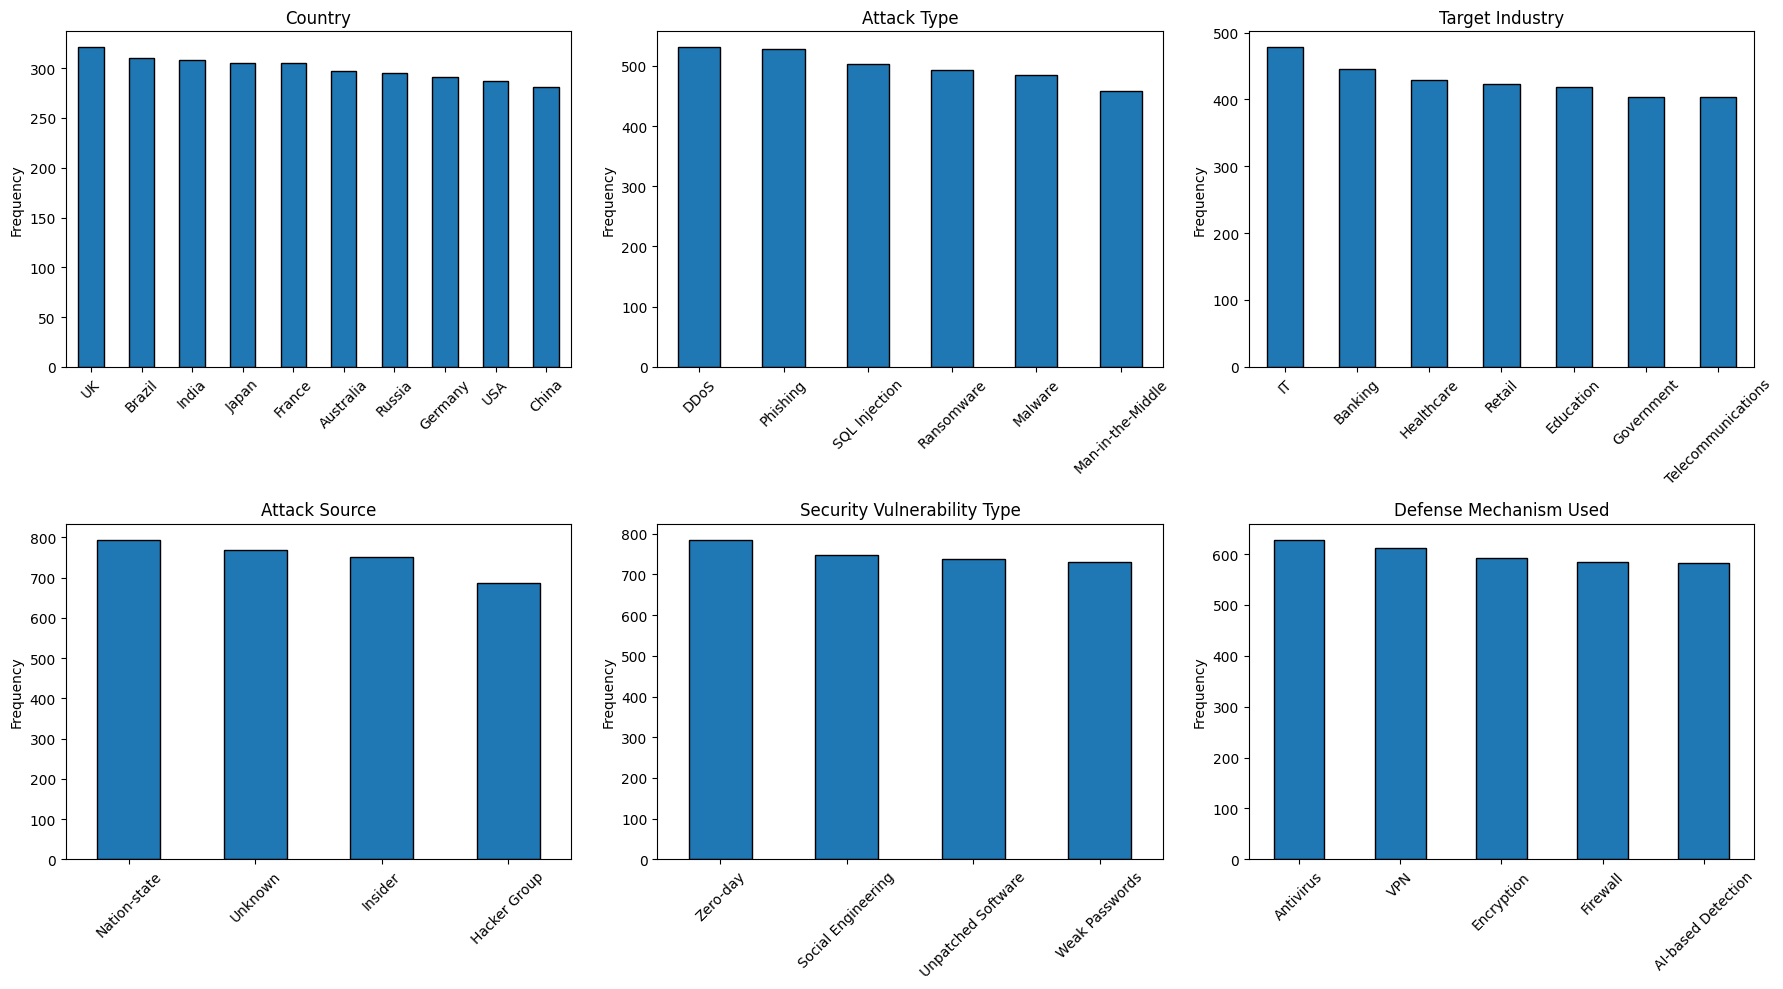

In [42]:
categorical_cols = [
    "country",
    "attack_type",
    "target_industry",
    "attack_source",
    "security_vulnerability_type",
    "defense_mechanism_used"
]

plt.figure(figsize=(18, 10))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 3, i)
    global_cybersecuirty_threats[col].value_counts().plot(kind="bar", edgecolor="black")
    plt.title(col.replace("_", " ").title())
    plt.xlabel("")
    plt.ylabel("Frequency")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Observation:**

- **Country**:

    The distribution of incidents by country looks quite balanced. The UK has the highest number of records, while China has the lowest, but the differences are not very large. This suggests that the dataset covers multiple countries in a fairly even way, which is helpful for comparing cyberattack severity across locations.

- **Attack Type**:

    Among the attack types, DDoS and Phishing appear most often, while Man-in-the-Middle has the lowest count. Still, all attack types are represented with relatively similar frequencies. This is useful because it allows a fair comparison of how different attack types relate to financial loss, user impact, and incident response time.

- **Target Industry**:

    The IT sector appears most frequently in the dataset, followed by Banking and Healthcare. Government and Telecommunications have the lowest counts, but again the differences are not too large. This means the dataset includes a good spread of industries, which is important for analyzing which sectors are more strongly affected by cyber incidents.

- **Attack Source**:

    The most common attack source is Nation-state, while Hacker Group appears least often. The four categories are still relatively balanced overall. This suggests that the dataset includes different kinds of threat actors and allows comparison of whether some sources are linked to more severe attacks than others.

- **Security Vulnerability Type**:

    The vulnerability categories are very evenly distributed. Zero-day appears slightly more often than the others, while Weak Passwords is the least frequent. Since the counts are very close, this variable looks suitable for comparing whether some vulnerability types are associated with higher severity than others.

- **Defense Mechanism Used**:

    The defense mechanisms also show a balanced distribution. Antivirus is the most common, while AI-based Detection appears least often. The differences are small, which means this variable can be used to explore whether certain defense mechanisms are linked to lower losses, fewer affected users, or shorter resolution times.

**Summary:**

    Overall, all six categorical variables are distributed quite evenly. At the same time, the balanced structure of the categories may also suggest that the dataset is curated rather than fully raw real-world data.

Let's check the distributions of all numeric features

<Figure size 1400x1000 with 0 Axes>

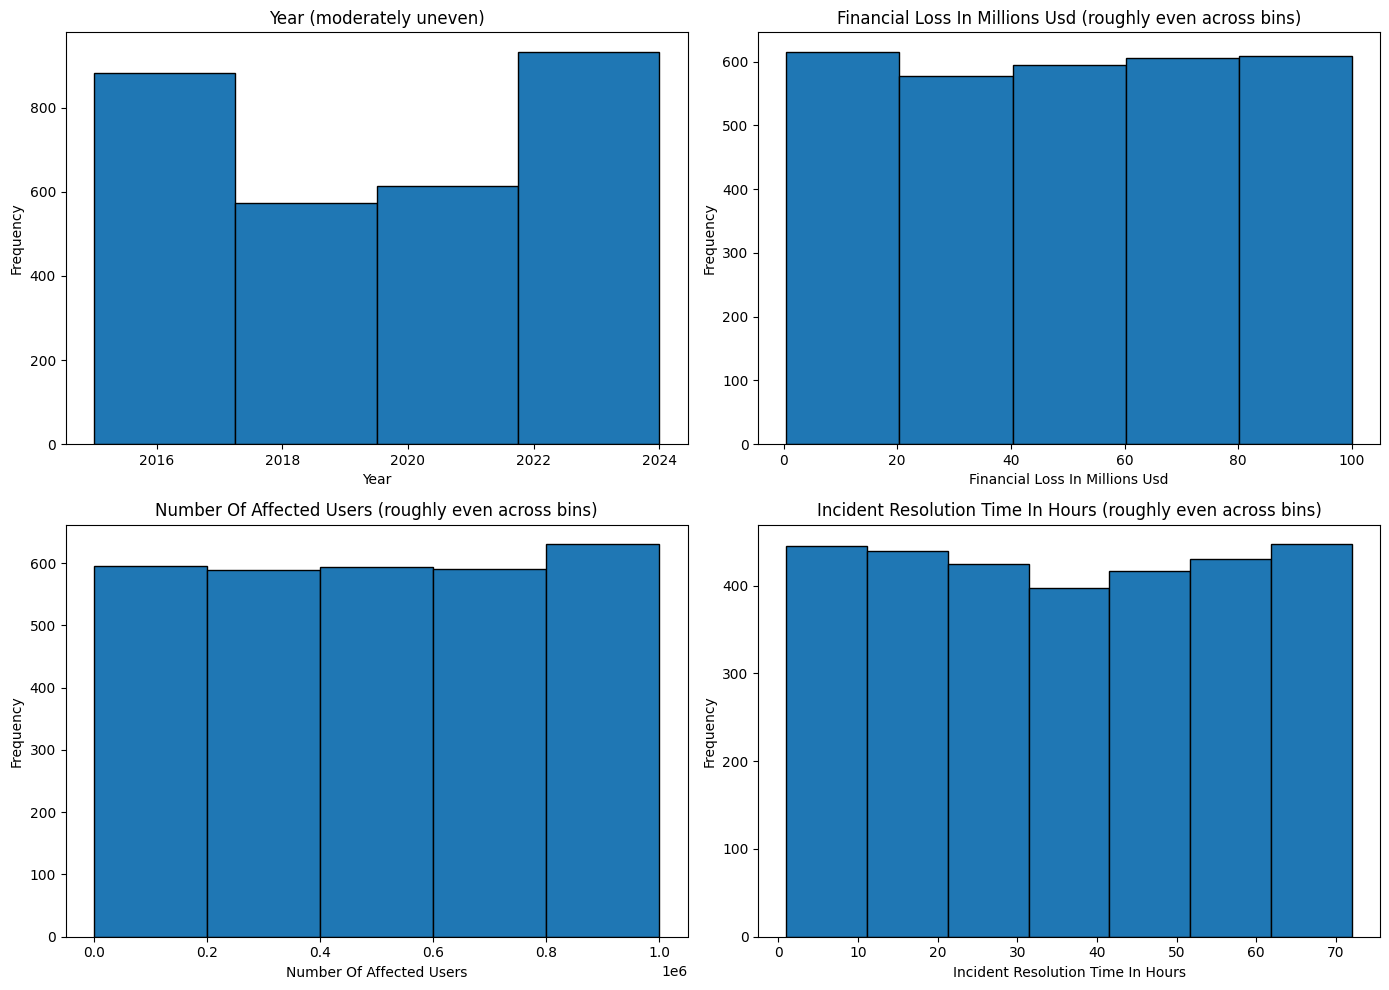

In [43]:
plt.figure(figsize=(14, 10))

"""
bin_settings = {
    "year": 4,
    "financial_loss_in_millions_usd": 5,
    "number_of_affected_users": 5,
    "incident_resolution_time_in_hours": 7
}

plt.figure(figsize=(14, 10))

for i, (col, bins) in enumerate(bin_settings.items(), 1):
    plt.subplot(2, 2, i)
    plt.hist(global_cybersecuirty_threats[col], bins=bins, edgecolor="black")
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()
"""

bin_settings = {
    "year": 4,
    "financial_loss_in_millions_usd": 5,
    "number_of_affected_users": 5,
    "incident_resolution_time_in_hours": 7
}

def classify_distribution_balance(series, bins):
    counts, _ = np.histogram(series.dropna(), bins=bins)
    
    # avoid division by zero if something strange happens
    mean_count = counts.mean()
    std_count = counts.std()
    
    # coefficient of variation
    cv = std_count / mean_count if mean_count != 0 else 0
    
    if cv < 0.10:
        return "roughly even across bins"
    elif cv < 0.25:
        return "moderately uneven"
    else:
        return "strongly uneven"

plt.figure(figsize=(14, 10))

for i, (col, bins) in enumerate(bin_settings.items(), 1):
    plt.subplot(2, 2, i)
    
    plt.hist(global_cybersecuirty_threats[col], bins=bins, edgecolor="black")
    
    balance_label = classify_distribution_balance(global_cybersecuirty_threats[col], bins)
    pretty_col = col.replace("_", " ").title()
    
    plt.title(f"{pretty_col} ({balance_label})")
    plt.xlabel(pretty_col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

**Observation:**

- **Year**:

    The distribution of `year` is modoretly uneven compared to the other numeric variables. The first and last bins have more records, while the middle bins have fewer. This means the incidents are not distributed perfectly evenly across time, but the difference is still not extreme. Overall, the dataset still covers the full period from 2015 to 2024 quite well.

- **Financial Loss in Millions USD**:

    The histogram of `financial_loss_in_millions_usd` looks quite evenly spread across the 5 bins. There is no strong concentration in only one part of the range, which means the dataset includes both lower-loss and higher-loss incidents in a balanced way.

- **Number of Affected Users**:

    The distribution of `number_of_affected_users` also looks roughly even across the bins. This suggests that the dataset contains incidents with both smaller and larger user impact, without being heavily concentrated in one range only. Because of this, the variable seems suitable for comparing how user impact changes across attack types and industries.

- **Incident Resolution Time in Hours**:

    The histogram for `incident_resolution_time_in_hours` is also quite evenly distributed, although there is a small drop in the middle range. In general, the values are spread across short, medium, and longer response times.

**Summary:**

Overall, the numeric variables show broad and fairly even distributions. Once again just like with categorical variables of `global_cybersecuirty_threats` the regular shape of the histograms again suggests that the data may be curated or synthetic, so the results should be interpreted as patterns within the dataset rather than exact real-world distributions.

#### 7.1.2. Correlations

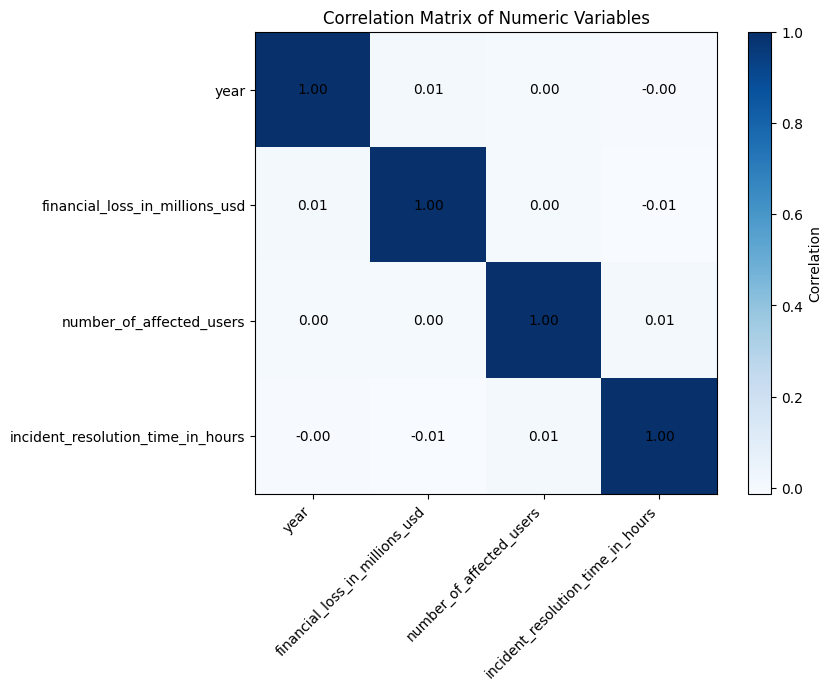

In [44]:
numeric_cols = [
    "year",
    "financial_loss_in_millions_usd",
    "number_of_affected_users",
    "incident_resolution_time_in_hours"
]

corr_matrix = global_cybersecuirty_threats[numeric_cols].corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, cmap='Blues', interpolation="nearest")
plt.colorbar(label="Correlation")

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha="right")
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)

for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center")

plt.title("Correlation Matrix of Numeric Variables")
plt.show()

**Observation:**

The correlation matrix shows that the numeric variables in `global_cybersecuirty_threats` dataframe have no strong relationship with each other. All off-diagonal values are very close to zero, which means there is no clear association between the main numeric features.

#### 7.1.3. Financial Loss by Attack Type

<Figure size 1000x600 with 0 Axes>

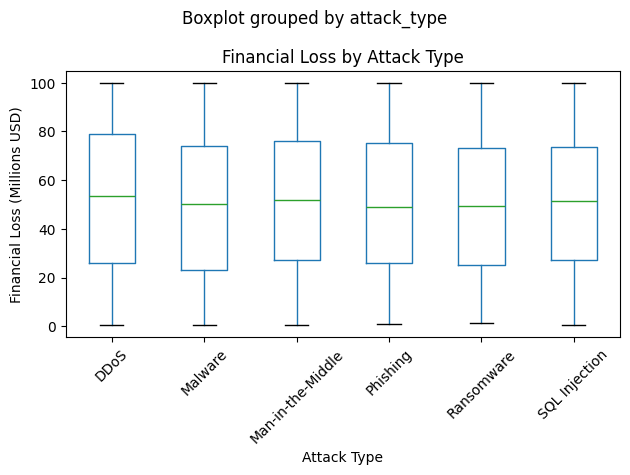

In [45]:
plt.figure(figsize=(10, 6))

global_cybersecuirty_threats.boxplot(
    column="financial_loss_in_millions_usd",
    by="attack_type",
    grid=False
)

plt.title("Financial Loss by Attack Type")
plt.xlabel("Attack Type")
plt.ylabel("Financial Loss (Millions USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observation:**

The boxplot shows that the distributions of financial loss are very similar across all attack types. The median values are close to each other, mostly around 50 million USD, which means no attack type stands out with a clearly higher typical financial loss.

#### 7.1.4. Number of Affected Users by Target Industry

<Figure size 1200x600 with 0 Axes>

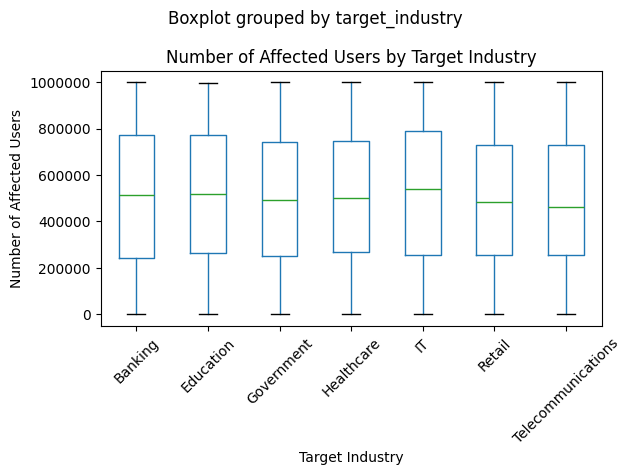

In [46]:
plt.figure(figsize=(12, 6))

global_cybersecuirty_threats.boxplot(
    column = "number_of_affected_users",
    by = "target_industry",
    grid=False
)

plt.title("Number of Affected Users by Target Industry")
plt.xlabel("Target Industry")
plt.ylabel("Number of Affected Users")
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

**Observation:**

The boxplot shows that the distributions of affected users are fairly similar across the different industries. Most medians are close to 500 000 users, which suggests that no single sector is clearly separated from the others in terms of typical user impact. This result suggests that industry alone may not be enough to explain user impact, and other factors should also be considered in the analysis.

Overall, this plot suggests that target industry does not create very strong differences in user impact in this dataset, although the IT sector appears to be slightly more affected than the others.

#### 7.1.5. Incident Resolution Time by Attack Source

<Figure size 1000x600 with 0 Axes>

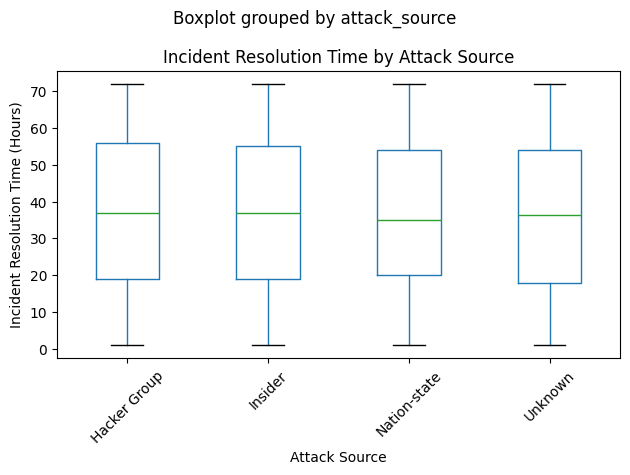

In [49]:
plt.figure(figsize=(10, 6))

global_cybersecuirty_threats.boxplot(
    column="incident_resolution_time_in_hours",
    by="attack_source",
    grid=False
)

plt.title("Incident Resolution Time by Attack Source")
plt.xlabel("Attack Source")
plt.ylabel("Incident Resolution Time (Hours)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observation:**

The boxplot shows that the distributions of incident resolution time are fairly similar across the different attack sources. Most median values are close to **35–40 hours**, which suggests that no single attack source clearly stands out in terms of typical resolution time.

Overall, this plot suggests that attack source alone does not seem to have a strong effect on incident resolution time in this dataset.

#### 7.1.6. Financial Loss by Securit Vulnerability Types

<Figure size 1000x600 with 0 Axes>

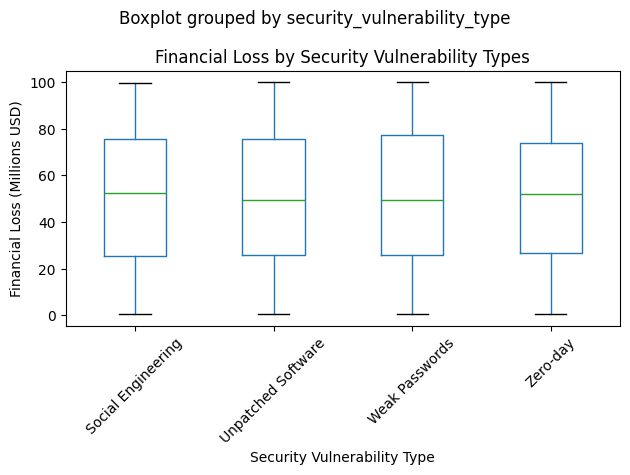

In [58]:
plt.figure(figsize=(10, 6))

global_cybersecuirty_threats.boxplot(
    column="financial_loss_in_millions_usd",
    by="security_vulnerability_type",
    grid=False
)

plt.title("Financial Loss by Security Vulnerability Types")
plt.xlabel("Security Vulnerability Type")
plt.ylabel("Financial Loss (Millions USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observation:**

The boxplot shows that the distributions of financial loss are very similar across the four vulnerability types. The median values are all close to **50 million USD**, which suggests that no single vulnerability category is clearly associated with higher typical financial loss.

Overall, this plot suggests that security vulnerability type alone does not appear to be a strong driver of financial loss in this dataset.

#### 7.1.7. Incident Resolution Time (Hours) by Defense Mechanism Used

<Figure size 1000x600 with 0 Axes>

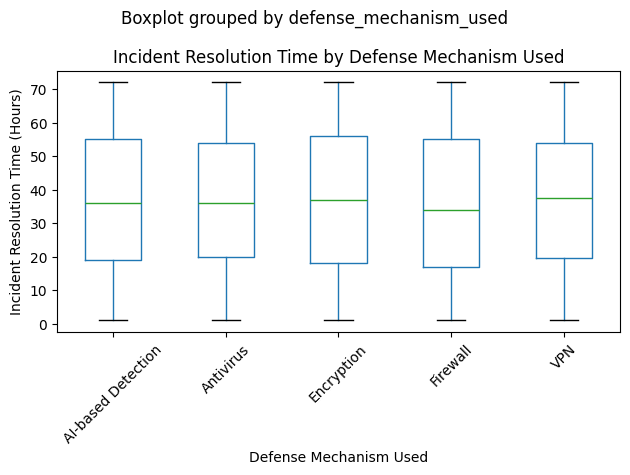

In [57]:
plt.figure(figsize=(10, 6))

global_cybersecuirty_threats.boxplot(
    column="incident_resolution_time_in_hours",
    by="defense_mechanism_used",
    grid=False
)

plt.title("Incident Resolution Time by Defense Mechanism Used")
plt.xlabel("Defense Mechanism Used")
plt.ylabel("Incident Resolution Time (Hours)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observation:**

The boxplot shows that the distributions of incident resolution time are quite similar across the different defense mechanisms. The median values are all close to around **35–38 hours**, which suggests that no single defense mechanism clearly stands out with much faster or slower typical resolution time.

Overall, this plot suggests that defense mechanism used alone does not appear to be a strong factor in incident resolution time in this dataset.

#### 7.1.8. Mean and Median Financial Loss by Attack Type

In [59]:
financial_loss_by_attack_type = (
    global_cybersecuirty_threats
    .groupby("attack_type", observed=False)["financial_loss_in_millions_usd"]
    .agg(["mean", "median", "min", "max", "count"])
    .sort_values(by="mean", ascending=False)
)

financial_loss_by_attack_type

,mean,median,min,max,count
attack_type,,,,,
DDoS,52.035631,53.46,0.50,99.99,531
Man-in-the-Middle,51.309085,52.04,0.54,99.71,459
Phishing,50.459905,49.08,0.92,99.98,529
SQL Injection,50.013042,51.26,0.72,99.99,503
Ransomware,49.653793,49.56,1.42,99.90,493
Malware,49.418454,50.02,0.54,99.72,485


**Observation:**

The table shows that **DDoS** is associated with the **highest average financial loss**, with a mean value of about **52.04 million USD**. It is followed closely by **Man-in-the-Middle** with about **51.31 million USD**.

Overall, the table answers the research sub-question ***"Which attack types are associated with the highest average financial loss?"*** by showing that **DDoS** is associated with the highest average financial loss, but the difference compared to the other attack types is small. This suggests that attack type alone is not a strong standalone factor for explaining financial loss in this dataset.